# OpenStreetMap Walking-Network Accessibility Analysis for Munich

This notebook analyzes walking-network accessibility to public transport stops in Munich using OpenStreetMap data. The workflow uses OSMnx to extract the pedestrian street network and transport stop locations, NetworkX to model the street system as a graph, and GeoPandas for spatial processing and visualization.

The analysis is intentionally limited in scope: it measures proximity to public transport stops through the walking network, not full door-to-door public transport travel time.

# Table of contents

  - [1 - Imports & Libraries](#1---imports--libraries)
  - [2 - Project Settings & Configuration](#2---project-settings--configuration)
  - [3 - Download walking network (OSM)](#3---download-walking-network-osm)
  - [4 - Network statistics](#4---network-statistics)
  - [5 - Convert graph to GeoDataFrames (nodes & edges)](#5---convert-graph-to-geodataframes-nodes--edges)
  - [6 - Visualize walking network](#6---visualize-walking-network)
  - [7 - Initial network extraction result](#7---initial-network-extraction-result)
- [Extract public transport stops from OSM](#extract-public-transport-stops-from-osm)

<a id="toc-automation"></a>
## TOC automation

Run the code cell below to automatically scan notebook headers, insert HTML anchors, and regenerate this Table of Contents. The notebook file will be updated in-place.

In [ ]:
# Regenerate TOC: scans this notebook, inserts anchors, and updates the TOC cell
from pathlib import Path
import re
import nbformat

# Resolve notebook path from current working directory
cwd = Path.cwd()
if cwd.name.lower() == "notebooks":
    nb_path = cwd / "01_munich_osmnx_accessibility.ipynb"
else:
    nb_path = cwd / "notebooks" / "01_munich_osmnx_accessibility.ipynb"

if not nb_path.exists():
    raise FileNotFoundError(f"Notebook not found at {nb_path}")

nb = nbformat.read(nb_path, as_version=4)
headers = []

def make_id(text):
    clean = re.sub(r"[^0-9a-zA-Z\- ]+", "", text)
    return clean.strip().lower().replace(" ", "-")

# Scan cells for markdown headers and ensure anchors
for idx, cell in enumerate(nb.cells):
    if cell.cell_type != "markdown":
        continue
    src = cell.source if isinstance(cell.source, str) else "\n".join(cell.source)
    lines = src.splitlines()
    if not lines:
        continue
    m = re.match(r"^(#{1,6})\s*(.+)", lines[0].strip())
    if not m:
        continue
    level = len(m.group(1))
    text = m.group(2).strip()
    # skip top title cell if it's the first cell
    if level == 1 and idx == 0:
        continue
    id_ = make_id(text)
    headers.append((level, text, id_))
    # add anchor if missing
    if f"<a id=\"{id_}\">" not in src and f"<a id='{id_}'>" not in src:
        new_src = f"<a id=\"{id_}\"></a>\n" + src
        cell.source = new_src

# Build TOC markdown
toc_lines = ["# Table of contents", ""]
for lvl, txt, id_ in headers:
    indent = "  " * (lvl - 1)
    toc_lines.append(f"{indent}- [{txt}](#{id_})")
toc_text = "\n".join(toc_lines)

# Replace or insert TOC cell after title
if len(nb.cells) > 1 and nb.cells[1].cell_type == "markdown":
    toc_src = nb.cells[1].source if isinstance(nb.cells[1].source, str) else "\n".join(nb.cells[1].source)
    if "Table of contents" in toc_src:
        nb.cells[1].source = toc_text
    else:
        nb.cells.insert(1, nbformat.v4.new_markdown_cell(toc_text))
else:
    nb.cells.insert(1, nbformat.v4.new_markdown_cell(toc_text))

# Save updated notebook
nbformat.write(nb, nb_path)
print("TOC regenerated in", nb_path)


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\repos\\Munich\\osm-network-accessibility-munich\\notebooks\\notebooks\\01_munich_osmnx_accessibility.ipynb'

<a id="imports-libraries"></a>
<a id="1---imports--libraries"></a>
## 1 - Imports & Libraries

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

<a id="project-settings"></a>
<a id="2---project-settings--configuration"></a>
## 2 - Project Settings & Configuration

In [3]:
# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = True

PLACE_NAME = "Munich, Bavaria, Germany"

PLACE_NAME

'Munich, Bavaria, Germany'

<a id="download-walking-network"></a>
<a id="3---download-walking-network-osm"></a>
## 3 - Download walking network (OSM)

In [4]:
# Download the walking street network for Munich from OpenStreetMap
G = ox.graph_from_place(
    PLACE_NAME,
    network_type="walk",
    simplify=True
)

# Project graph to a local metric coordinate system for distance calculations
G_proj = ox.project_graph(G)

G_proj

<a id="network-statistics"></a>
<a id="4---network-statistics"></a>
## 4 - Network statistics

In [6]:
# Basic network statistics
stats = ox.basic_stats(G_proj)

# Get Munich boundary polygon to calculate area
munich_boundary = ox.geocode_to_gdf(PLACE_NAME)
munich_boundary_proj = munich_boundary.to_crs(edges.crs if "edges" in globals() else ox.graph_to_gdfs(G_proj, nodes=False).crs)

area_m2 = munich_boundary_proj.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

selected_stats = {
    "Number of nodes": stats.get("n"),
    "Number of edges": stats.get("m"),
    "Total edge length (km)": stats.get("edge_length_total", 0) / 1000,
    "Average edge length (m)": stats.get("edge_length_avg"),
    "Intersection count": stats.get("intersection_count"),
    "Munich boundary area (km²)": area_km2,
    "Street density (km/km²)": (stats.get("edge_length_total", 0) / 1000) / area_km2,
    "Intersection density (count/km²)": stats.get("intersection_count", 0) / area_km2,
}

pd.Series(selected_stats)

Number of nodes                     148230.000000
Number of edges                     387928.000000
Total edge length (km)               15281.244298
Average edge length (m)                 39.391960
Intersection count                  105985.000000
Munich boundary area (km²)             310.737328
Street density (km/km²)                 49.177369
Intersection density (count/km²)       341.075856
dtype: float64

<a id="convert-graph-to-geodataframes"></a>
<a id="5---convert-graph-to-geodataframes-nodes--edges"></a>
## 5 - Convert graph to GeoDataFrames (nodes & edges)

In [10]:
# Convert graph to GeoDataFrames for nodes and edges
nodes, edges = ox.graph_to_gdfs(G_proj)

print(f"Nodes: {len(nodes):,}")
print(f"Edges: {len(edges):,}")

nodes.head()


Nodes: 148,230
Edges: 387,928


,y,x,street_count,highway,railway,ref,geometry
osmid,,,,,,,
128236,5.339065e+06,678051.022963,1,NaN,NaN,NaN,POINT (678051.023 5339064.73)
1399723741,5.339058e+06,678048.766587,4,NaN,NaN,NaN,POINT (678048.767 5339057.874)
128239,5.338986e+06,678321.975388,1,NaN,NaN,NaN,POINT (678321.975 5338985.899)
9497553538,5.338987e+06,678326.056827,3,NaN,NaN,NaN,POINT (678326.057 5338987.194)
128258,5.337587e+06,679336.821688,1,NaN,NaN,NaN,POINT (679336.822 5337586.869)


In [11]:
# Check the coordinate reference system and geometry types
print("Nodes CRS:", nodes.crs)
print("Edges CRS:", edges.crs)

print("\nNode geometry types:")
print(nodes.geometry.geom_type.value_counts())

print("\nEdge geometry types:")
print(edges.geometry.geom_type.value_counts())

Nodes CRS: EPSG:32632
Edges CRS: EPSG:32632

Node geometry types:
Point    148230
Name: count, dtype: int64

Edge geometry types:
LineString    387928
Name: count, dtype: int64


<a id="visualize-walking-network"></a>
<a id="6---visualize-walking-network"></a>
## 6 - Visualize walking network

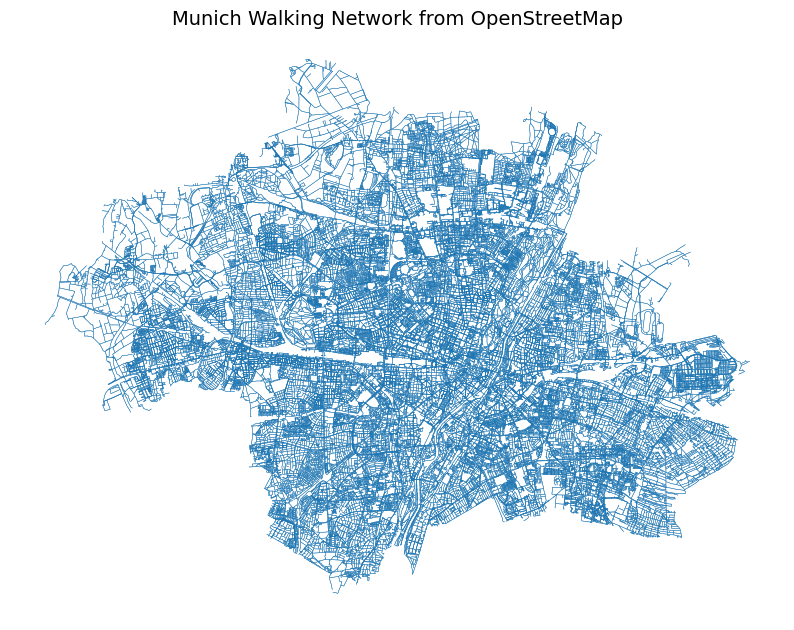

WindowsPath('d:/repos/Munich/osm-network-accessibility-munich/outputs/munich_walking_network.png')

In [13]:
# Visualize the walking network
fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, linewidth=0.3)
ax.set_title("Munich Walking Network from OpenStreetMap", fontsize=14)
ax.axis("off")

output_path = OUTPUT_DIR / "munich_walking_network.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

<a id="initial-network-extraction-result"></a>
<a id="7---initial-network-extraction-result"></a>
## 7 - Initial network extraction result

The extracted Munich walking network contains 148,230 nodes and 387,928 edges. After projection to EPSG:32632, the network is represented in meters, which makes it suitable for distance-based accessibility calculations. The node layer consists entirely of point geometries, while the edge layer consists entirely of line geometries. This confirms that the OpenStreetMap walking network was successfully converted into spatial tables for analysis and visualization.

<a id="extract-public-transport-stops-from-osm"></a>
# Extract public transport stops from OSM